# Avatar Project — Data Understanding Phase
## Dataset: Facial Expression (Non-Verbal Gestures)
**Methodology:** TDSP | **Phase:** Data Understanding

---
**Dataset source:** https://www.kaggle.com/datasets/shawon10/facial-expression

**Emotion codes:** `AN`=Angry · `DI`=Disgust · `FE`=Fear · `HA`=Happy · `NE`=Neutral · `SA`=Sad · `SU`=Surprise

## 1.  Import Libraries

In [4]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully.')

Libraries imported successfully.


## 2. Define Dataset Path

In [7]:
# Update this path to match where you extracted archive.zip
DATASET_PATH = './archive/facial'

EMOTION_MAP = {
    'AN': 'Angry',
    'DI': 'Disgust',
    'FE': 'Fear',
    'HA': 'Happy',
    'NE': 'Neutral',
    'SA': 'Sad',
    'SU': 'Surprise'
}

all_files = [f for f in os.listdir(DATASET_PATH) if f.lower().endswith(('.jpg', '.jpeg'))]
print(f'Dataset path : {DATASET_PATH}')
print(f'Total images : {len(all_files)}')

Dataset path : ./archive/facial
Total images : 291


## 3. Categorize Files by Naming Pattern

In [11]:
structured = []
simple_num = []
y_series   = []
celebrity  = []
other      = []

for f in all_files:
    if re.match(r'^[A-Z]{2}\.(AN|DI|FE|HA|NE|SA|SU)\d', f):
        structured.append(f)
    elif re.match(r'^\d+[ab]\.jpg', f, re.IGNORECASE):
        simple_num.append(f)
    elif re.match(r'^y\d+\.', f, re.IGNORECASE):
        y_series.append(f)
    elif re.match(r'^[A-Z][a-z]+[A-Z]?\w*_\d+', f):
        celebrity.append(f)
    else:
        other.append(f)

print('File groups identified:')
print(f'  Structured (XX.EM.N.jpg) — labeled   : {len(structured)}')
print(f'  Simple numbered (1a/1b)  — unlabeled : {len(simple_num)}')
print(f'  Y-series (y01..y38)      — unlabeled : {len(y_series)}')
print(f'  Celebrity names          — unlabeled : {len(celebrity)}')
print(f'  Other/misc               — unlabeled : {len(other)}')
print(f'  TOTAL                               : {len(all_files)}')

File groups identified:
  Structured (XX.EM.N.jpg) — labeled   : 68
  Simple numbered (1a/1b)  — unlabeled : 71
  Y-series (y01..y38)      — unlabeled : 38
  Celebrity names          — unlabeled : 102
  Other/misc               — unlabeled : 12
  TOTAL                               : 291


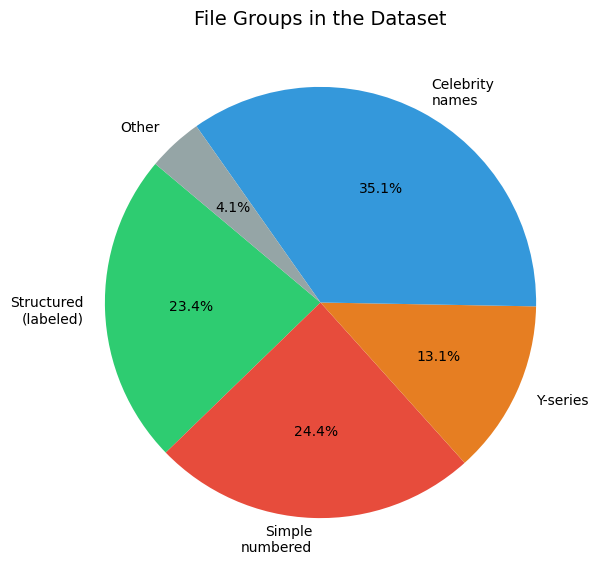

In [13]:
# Pie chart: file groups breakdown
group_labels = ['Structured\n(labeled)', 'Simple\nnumbered', 'Y-series', 'Celebrity\nnames', 'Other']
group_counts = [len(structured), len(simple_num), len(y_series), len(celebrity), len(other)]
colors = ['#2ecc71', '#e74c3c', '#e67e22', '#3498db', '#95a5a6']

plt.figure(figsize=(7, 7))
plt.pie(group_counts, labels=group_labels, autopct='%1.1f%%', colors=colors, startangle=140)
plt.title('File Groups in the Dataset', fontsize=14)
plt.show()

## 4. Label Extraction (Structured Files Only)

In [16]:
records = []
for f in structured:
    parts = f.split('.')
    subject      = parts[0]
    emotion_code = re.sub(r'\d', '', parts[1])
    emotion_label = EMOTION_MAP.get(emotion_code, 'Unknown')
    records.append({
        'filename'     : f,
        'subject_code' : subject,
        'emotion_code' : emotion_code,
        'emotion_label': emotion_label
    })

df = pd.DataFrame(records)
print(f'Labeled images: {len(df)}')
print()
print(df.head(14).to_string(index=False))

Labeled images: 68

      filename subject_code emotion_code emotion_label
 KA.AN2.40.jpg           KA           AN         Angry
 KA.DI2.43.jpg           KA           DI       Disgust
 KA.FE2.46.jpg           KA           FE          Fear
 KA.HA2.30.jpg           KA           HA         Happy
 KA.NE2.27.jpg           KA           NE       Neutral
 KA.SA2.34.jpg           KA           SA           Sad
 KA.SU2.37.jpg           KA           SU      Surprise
KL.AN2.168.jpg           KL           AN         Angry
KL.DI2.171.jpg           KL           DI       Disgust
KL.FE2.175.jpg           KL           FE          Fear
KL.HA2.159.jpg           KL           HA         Happy
KL.NE2.156.jpg           KL           NE       Neutral
KL.SA2.162.jpg           KL           SA           Sad
KL.SU2.165.jpg           KL           SU      Surprise


## 5. Class Distribution (Labeled Files)

In [19]:
emotion_counts = df['emotion_label'].value_counts().reset_index()
emotion_counts.columns = ['Emotion', 'Count']
emotion_counts['%'] = (emotion_counts['Count'] / emotion_counts['Count'].sum() * 100).round(1)
print(emotion_counts.to_string(index=False))

 Emotion  Count    %
   Angry     10 14.7
    Fear     10 14.7
   Happy     10 14.7
 Neutral     10 14.7
     Sad     10 14.7
Surprise     10 14.7
 Disgust      8 11.8


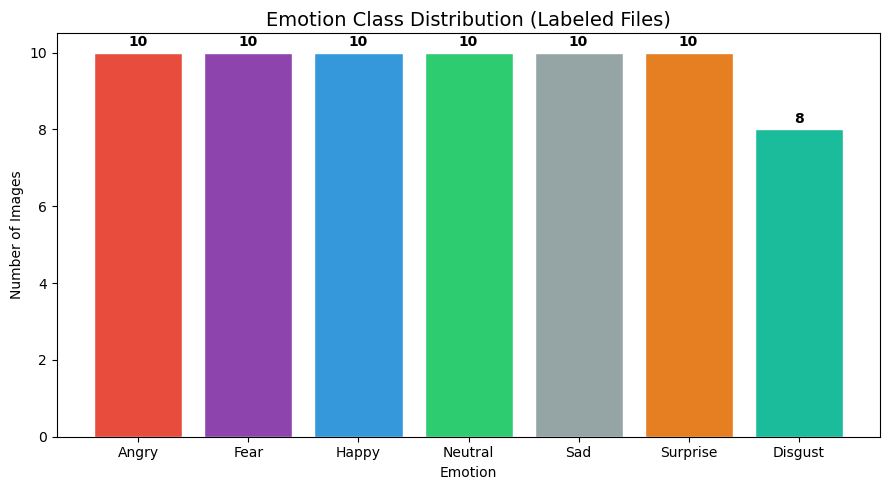

In [21]:
colors_bar = ['#e74c3c','#8e44ad','#3498db','#2ecc71','#95a5a6','#e67e22','#1abc9c']

plt.figure(figsize=(9, 5))
bars = plt.bar(emotion_counts['Emotion'], emotion_counts['Count'], color=colors_bar, edgecolor='white')

for bar, count in zip(bars, emotion_counts['Count']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, str(count),
             ha='center', va='bottom', fontweight='bold')

plt.title('Emotion Class Distribution (Labeled Files)', fontsize=14)
plt.xlabel('Emotion')
plt.ylabel('Number of Images')
plt.tight_layout()
plt.show()

Images per subject:
subject_code
KA    7
KL    7
KR    7
MK    7
NA    7
TM    7
UY    7
YM    7
KM    6
NM    6


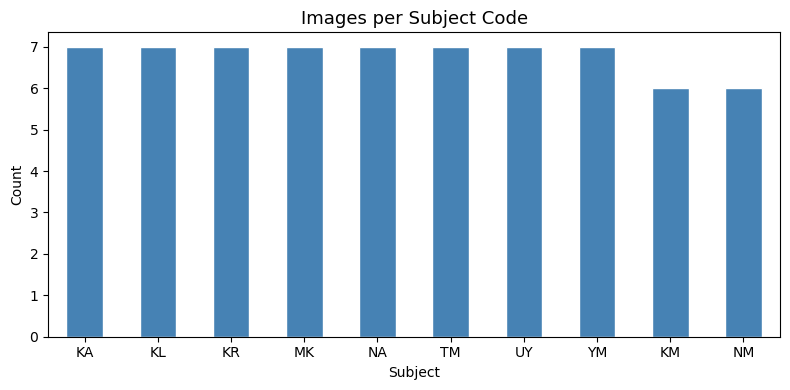

In [23]:
# Distribution per subject (who was photographed)
subject_counts = df['subject_code'].value_counts()
print('Images per subject:')
print(subject_counts.to_string())

plt.figure(figsize=(8, 4))
subject_counts.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Images per Subject Code', fontsize=13)
plt.xlabel('Subject')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Image Properties Analysis

In [26]:
img_info = []

for f in all_files[:100]:
    img_path = os.path.join(DATASET_PATH, f)
    with Image.open(img_path) as img:
        img_info.append({
            'filename': f,
            'width'   : img.size[0],
            'height'  : img.size[1],
            'mode'    : img.mode
        })

df_info = pd.DataFrame(img_info)

print('Image mode counts (L=Grayscale, RGB=Color):')
print(df_info['mode'].value_counts().to_string())
print()
print('Width  — min:', df_info['width'].min(),  ' max:', df_info['width'].max(),  ' mean:', round(df_info['width'].mean(), 1))
print('Height — min:', df_info['height'].min(), ' max:', df_info['height'].max(), ' mean:', round(df_info['height'].mean(), 1))
print()
print('Unique sizes found:', df_info[['width','height']].drop_duplicates().shape[0])

Image mode counts (L=Grayscale, RGB=Color):
mode
L      71
RGB    29

Width  — min: 38  max: 296  mean: 158.4
Height — min: 58  max: 375  mean: 193.2

Unique sizes found: 30


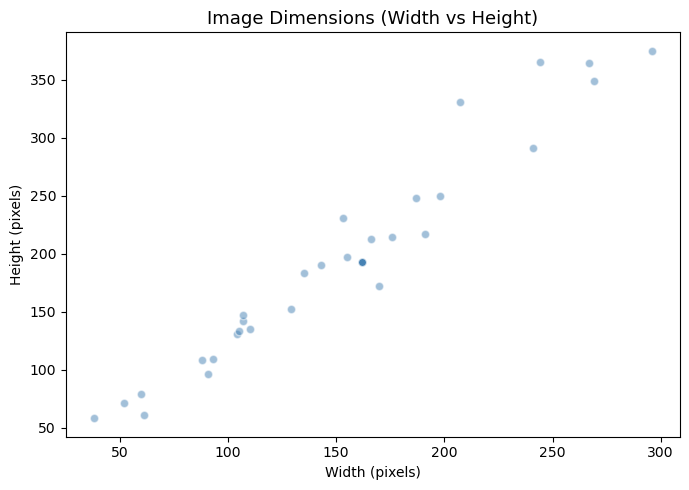

In [28]:
# Scatter plot: width vs height
plt.figure(figsize=(7, 5))
plt.scatter(df_info['width'], df_info['height'], alpha=0.5, color='steelblue', edgecolor='white')
plt.title('Image Dimensions (Width vs Height)', fontsize=13)
plt.xlabel('Width (pixels)')
plt.ylabel('Height (pixels)')
plt.tight_layout()
plt.show()

## 7. Sample Images per Emotion (Labeled Files)

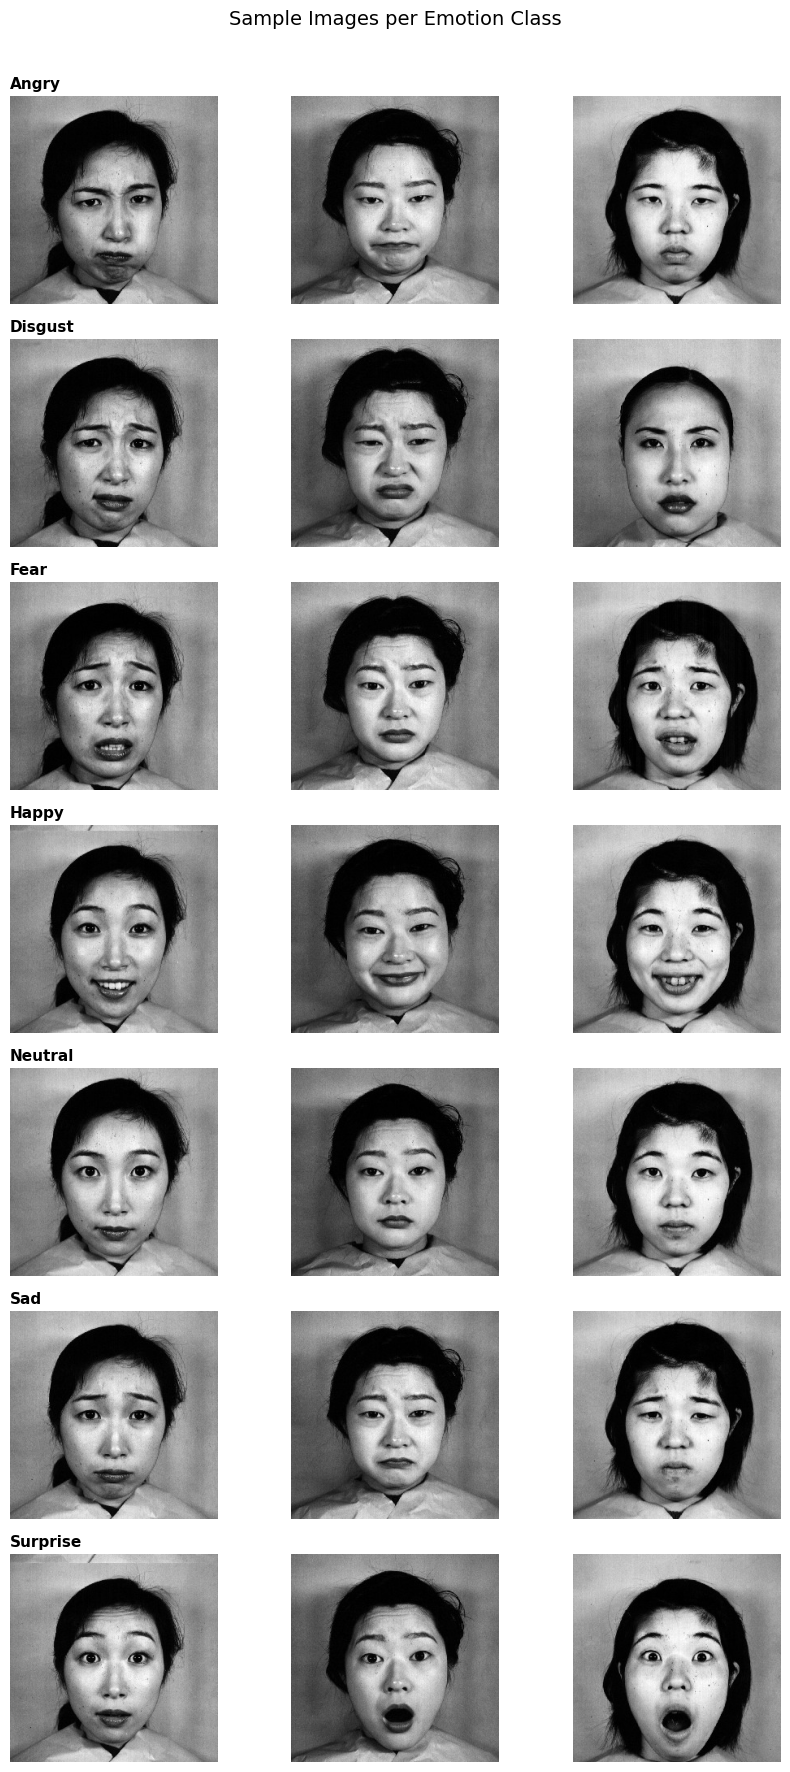

In [31]:
emotions = list(EMOTION_MAP.values())
n_samples = 3

fig, axes = plt.subplots(len(emotions), n_samples, figsize=(n_samples * 3, len(emotions) * 2.5))

for row, emotion in enumerate(emotions):
    subset = df[df['emotion_label'] == emotion]['filename'].tolist()[:n_samples]
    for col in range(n_samples):
        ax = axes[row, col]
        if col < len(subset):
            img_path = os.path.join(DATASET_PATH, subset[col])
            img = mpimg.imread(img_path)
            ax.imshow(img, cmap='gray' if len(img.shape) == 2 else None)
        ax.axis('off')
        if col == 0:
            ax.set_title(emotion, fontsize=11, fontweight='bold', loc='left')

plt.suptitle('Sample Images per Emotion Class', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 8. Pixel Intensity Analysis

In [34]:
pixel_stats = []

for emotion in emotions:
    subset = df[df['emotion_label'] == emotion]['filename'].tolist()
    values = []
    for fname in subset:
        img = np.array(Image.open(os.path.join(DATASET_PATH, fname)).convert('L'))
        values.extend(img.flatten().tolist())
    pixel_stats.append({
        'Emotion'   : emotion,
        'Mean Pixel': round(np.mean(values), 1),
        'Std Pixel' : round(np.std(values), 1),
        'Min Pixel' : int(np.min(values)),
        'Max Pixel' : int(np.max(values))
    })

df_pixels = pd.DataFrame(pixel_stats)
print(df_pixels.to_string(index=False))

 Emotion  Mean Pixel  Std Pixel  Min Pixel  Max Pixel
   Angry       108.9       63.2          0        255
 Disgust       108.0       62.8          0        255
    Fear       106.8       60.9          0        254
   Happy       113.1       61.3          0        255
 Neutral       111.2       60.8          0        255
     Sad       114.5       62.5          0        255
Surprise       114.0       62.1          0        255


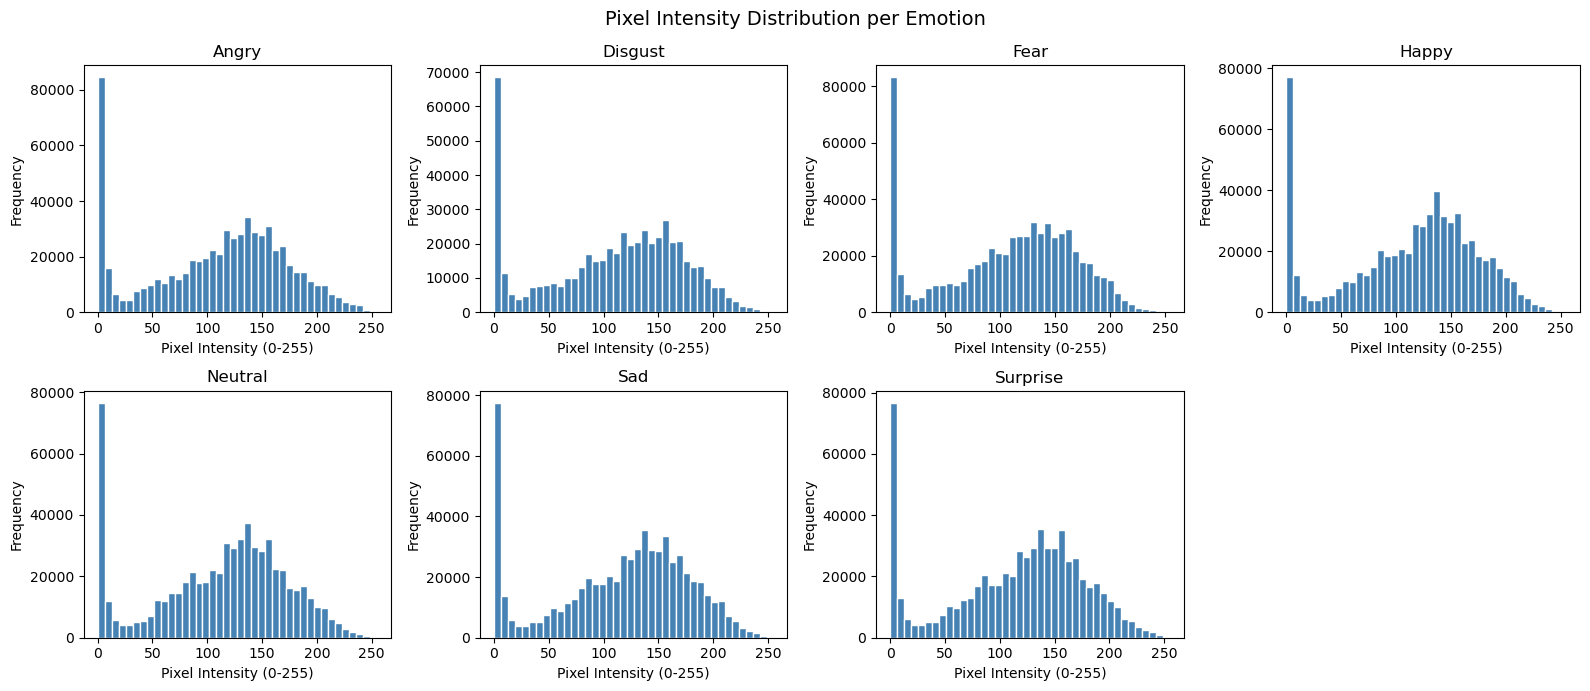

In [36]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, emotion in enumerate(emotions):
    subset = df[df['emotion_label'] == emotion]['filename'].tolist()
    values = []
    for fname in subset:
        img = np.array(Image.open(os.path.join(DATASET_PATH, fname)).convert('L'))
        values.extend(img.flatten().tolist())
    axes[i].hist(values, bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(emotion)
    axes[i].set_xlabel('Pixel Intensity (0-255)')
    axes[i].set_ylabel('Frequency')

for j in range(len(emotions), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Pixel Intensity Distribution per Emotion', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Class Imbalance Check

In [39]:
max_count = emotion_counts['Count'].max()
min_count = emotion_counts['Count'].min()
imbalance_ratio = round(max_count / min_count, 2)

max_class = emotion_counts.loc[emotion_counts['Count'].idxmax(), 'Emotion']
min_class = emotion_counts.loc[emotion_counts['Count'].idxmin(), 'Emotion']

print(f'Largest class   : {max_class} ({max_count} images)')
print(f'Smallest class  : {min_class} ({min_count} images)')
print(f'Imbalance ratio : {imbalance_ratio}x')

if imbalance_ratio > 2:
    print('\nClass imbalance detected. Consider oversampling or class weighting.')
else:
    print('\nClasses are relatively balanced.')

Largest class   : Angry (10 images)
Smallest class  : Disgust (8 images)
Imbalance ratio : 1.25x

Classes are relatively balanced.


## 10. Data Understanding Summary

In [42]:
labeled_pct   = round(len(structured) / len(all_files) * 100, 1)
unlabeled_pct = round(100 - labeled_pct, 1)

print('=' * 52)
print('          DATA UNDERSTANDING SUMMARY')
print('=' * 52)
print(f'  Total images in dataset : {len(all_files)}')
print(f'  Labeled images          : {len(structured)} ({labeled_pct}%)')
print(f'  Unlabeled images        : {len(all_files)-len(structured)} ({unlabeled_pct}%)')
print(f'  Emotion classes         : {list(EMOTION_MAP.values())}')
print(f'  Unique subjects         : {df["subject_code"].nunique()}')
print(f'  Image formats           : Mixed sizes & modes (RGB + Grayscale)')
print(f'  Class imbalance ratio   : {imbalance_ratio}x')
print('=' * 52)
print()
print('KEY OBSERVATIONS FOR NEXT STEPS:')
print(f'  1. Only {labeled_pct}% of images are labeled — labeling strategy needed for the rest.')
print('  2. Images have varying dimensions — resizing required before modeling.')
print('  3. Mixed color modes (RGB + Grayscale) — normalization needed.')
print('  4. Small labeled sample (68 images) — data augmentation is essential.')

          DATA UNDERSTANDING SUMMARY
  Total images in dataset : 291
  Labeled images          : 68 (23.4%)
  Unlabeled images        : 223 (76.6%)
  Emotion classes         : ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']
  Unique subjects         : 10
  Image formats           : Mixed sizes & modes (RGB + Grayscale)
  Class imbalance ratio   : 1.25x

KEY OBSERVATIONS FOR NEXT STEPS:
  1. Only 23.4% of images are labeled — labeling strategy needed for the rest.
  2. Images have varying dimensions — resizing required before modeling.
  3. Mixed color modes (RGB + Grayscale) — normalization needed.
  4. Small labeled sample (68 images) — data augmentation is essential.
